In [1]:
import pandas as pd

df = pd.read_csv("Combined12.csv")
df.head()

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
0,971.5,0.25,9.0,7.0,10.7,0.0,0,0
1,972.3,0.97,10.5,6.7,13.5,0.0,0,0
2,972.4,0.74,6.5,3.9,9.1,0.0,0,0
3,973.2,0.15,5.1,3.7,7.7,0.0,0,0
4,975.7,0.12,5.2,2.6,8.3,0.0,0,0


In [2]:
df.isnull().sum()

Pressure            0
global_radiation    0
temp_mean(c)        0
temp_min(c)         0
temp_max(c)         0
Wind_Speed          0
Wind_Bearing        0
normalized_label    0
dtype: int64

In [3]:
df[df["temp_mean(c)"] > 8]

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
0,971.5,0.25,9.0,7.0,10.7,0.00,0,0
1,972.3,0.97,10.5,6.7,13.5,0.00,0,0
7,976.8,0.35,9.2,7.7,9.2,0.00,0,0
8,977.3,0.59,11.2,9.3,13.2,0.00,0,0
9,977.7,0.64,9.0,5.4,12.1,0.00,0,0
...,...,...,...,...,...,...,...,...
533307,1015.0,2.11,19.7,15.0,27.3,3.14,325,0
533308,1015.0,2.11,19.7,15.0,27.3,24.07,147,2
533309,1015.0,2.11,19.7,15.0,27.3,3.30,247,0
533310,1015.0,2.11,19.7,15.0,27.3,25.41,308,2


In [4]:
df[df["Pressure"] > 973]

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
3,973.2,0.15,5.1,3.7,7.7,0.00,0,0
4,975.7,0.12,5.2,2.6,8.3,0.00,0,0
5,975.9,0.18,4.9,3.8,7.4,0.00,0,0
6,976.8,0.27,5.8,4.4,7.1,0.00,0,1
7,976.8,0.35,9.2,7.7,9.2,0.00,0,0
...,...,...,...,...,...,...,...,...
533307,1015.0,2.11,19.7,15.0,27.3,3.14,325,0
533308,1015.0,2.11,19.7,15.0,27.3,24.07,147,2
533309,1015.0,2.11,19.7,15.0,27.3,3.30,247,0
533310,1015.0,2.11,19.7,15.0,27.3,25.41,308,2


In [5]:
df[df["Wind_Speed"] > 5]

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
49,985.1,0.11,9.2,7.1,10.3,37.03,150,2
53,985.4,0.70,7.2,5.4,9.0,36.64,140,3
60,986.0,0.40,8.1,6.2,10.3,38.64,160,2
61,986.1,0.17,4.0,0.1,8.0,27.16,169,2
63,986.3,0.15,10.0,8.6,7.5,30.59,130,2
...,...,...,...,...,...,...,...,...
533299,1015.0,2.11,19.7,15.0,27.3,15.26,130,2
533305,1015.0,2.11,19.7,15.0,27.3,17.19,70,2
533306,1015.0,2.11,19.7,15.0,27.3,6.15,130,0
533308,1015.0,2.11,19.7,15.0,27.3,24.07,147,2


In [6]:
df.groupby("Wind_Bearing")["temp_mean(c)"].mean().reset_index()

,Wind_Bearing,temp_mean(c)
0,0,12.900667
1,1,12.639333
2,2,13.257914
3,3,13.434857
4,4,12.034146
...,...,...
352,355,13.532303
353,356,13.302091
354,357,12.670526
355,358,13.118056


In [7]:
df.groupby("Wind_Bearing")["Pressure"].mean().reset_index()

,Wind_Bearing,Pressure
0,0,1011.963955
1,1,1011.573837
2,2,1012.509870
3,3,1011.790571
4,4,1008.677236
...,...,...
352,355,1013.497472
353,356,1012.199049
354,357,1012.212368
355,358,1012.605417


In [8]:
weather_analysis = df.groupby("Wind_Bearing").agg({
    "Pressure": "mean",
    "global_radiation": "mean",
    "temp_mean(c)": "mean",
    "temp_min(c)": "mean",
    "temp_max(c)": "mean",
    "Wind_Speed": "mean"
}).reset_index()

weather_analysis

,Wind_Bearing,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed
0,0,1011.963955,1.362962,12.900667,8.802834,17.210516,3.783831
1,1,1011.573837,1.299227,12.639333,8.693327,16.886392,12.723740
2,2,1012.509870,1.351341,13.257914,9.138920,17.442458,10.830317
3,3,1011.790571,1.429057,13.434857,9.239429,17.891714,6.620229
4,4,1008.677236,1.136667,12.034146,8.418699,15.824390,13.307724
...,...,...,...,...,...,...,...
352,355,1013.497472,1.450562,13.532303,9.329213,17.834831,8.521067
353,356,1012.199049,1.345913,13.302091,9.285741,17.585361,6.606502
354,357,1012.212368,1.319605,12.670526,8.722368,16.863158,7.144868
355,358,1012.605417,1.400653,13.118056,8.919583,17.501250,8.735458


<module 'matplotlib.pyplot' from 'c:\\Users\\jagad\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\matplotlib\\pyplot.py'>

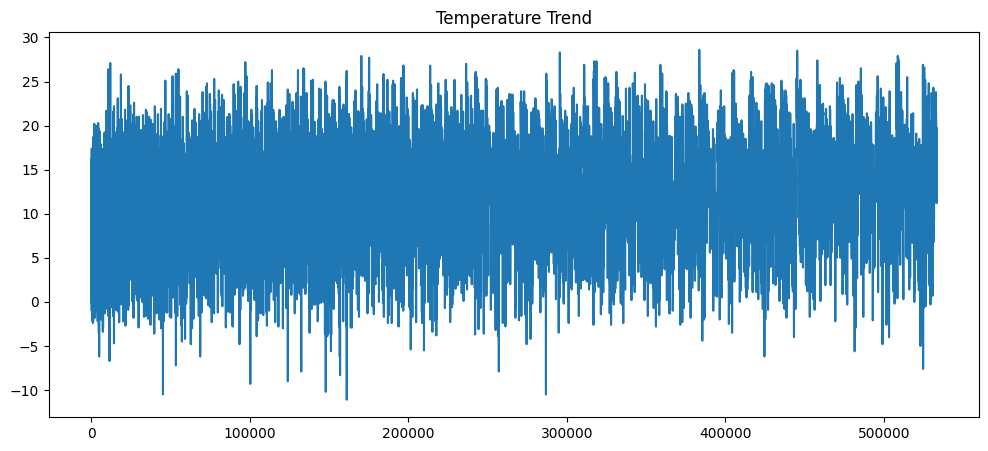

In [12]:
df["temp_mean(c)"].plot(figsize=(12,5))

plt.title("Temperature Trend")
plt

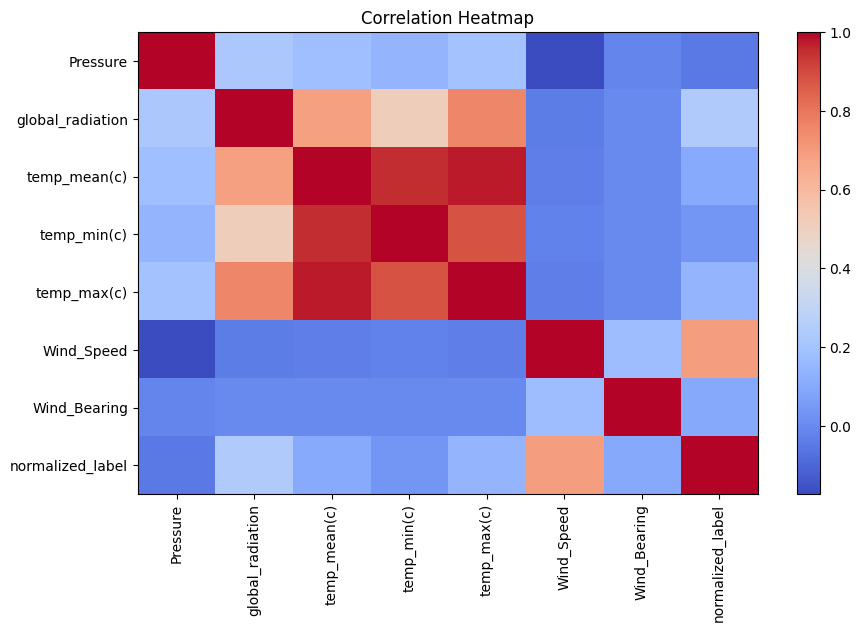

In [13]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=["number"])

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()